<a href="https://colab.research.google.com/github/Nagaojeswi/iris-flower-/blob/main/iris_flower_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:


iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["Species"] = iris.target
df["Species"] = df["Species"].map({
    0:"Setosa",
    1:"Versicolor",
    2:"Virginica"
})

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  Species  
0  Setosa  
1  Setosa  
2  Setosa  
3  Setosa  
4  Setosa  


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumns")
print(df.columns)

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())

Dataset Shape: (150, 5)

Columns
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'Species'],
      dtype='object')

Missing Values
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64

Statistical Summary
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std     

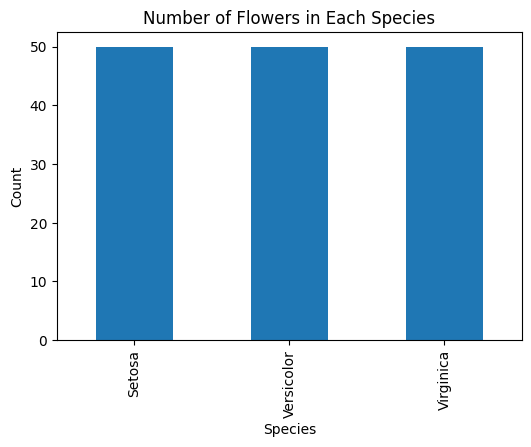

In [4]:


plt.figure(figsize=(6,4))

df["Species"].value_counts().plot(kind="bar")

plt.title("Number of Flowers in Each Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

In [5]:
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 120
Testing Samples: 30


In [6]:
models = {

    "Logistic Regression": LogisticRegression(),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "KNN": KNeighborsClassifier(),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )

}

accuracy_scores = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    accuracy_scores[name] = accuracy

    print(name)
    print("Accuracy:", round(accuracy*100,2),"%")
    print("-----------------------------------")

Logistic Regression
Accuracy: 100.0 %
-----------------------------------
Decision Tree
Accuracy: 100.0 %
-----------------------------------
KNN
Accuracy: 100.0 %
-----------------------------------
Random Forest
Accuracy: 100.0 %
-----------------------------------


In [7]:
best_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

best_model.fit(X_train,y_train)

prediction = best_model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,prediction))

print("\nClassification Report\n")

print(classification_report(
    y_test,
    prediction,
    target_names=iris.target_names
))

print("\nConfusion Matrix\n")

print(confusion_matrix(y_test,prediction))

Accuracy: 1.0

Classification Report

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


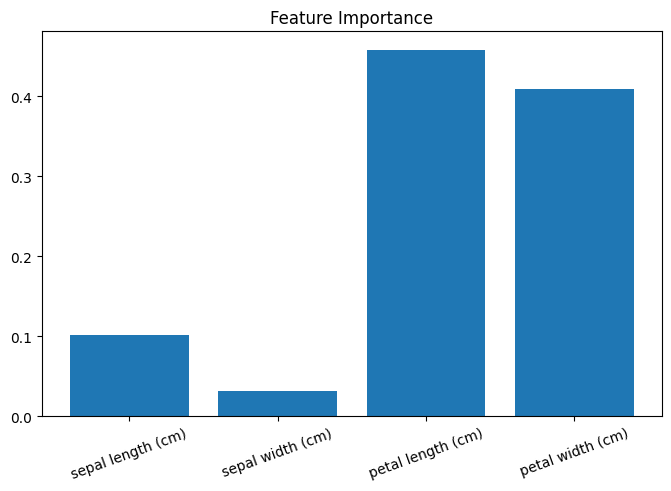

In [8]:
importance = best_model.feature_importances_

plt.figure(figsize=(8,5))

plt.bar(
    iris.feature_names,
    importance
)

plt.title("Feature Importance")

plt.xticks(rotation=20)

plt.show()

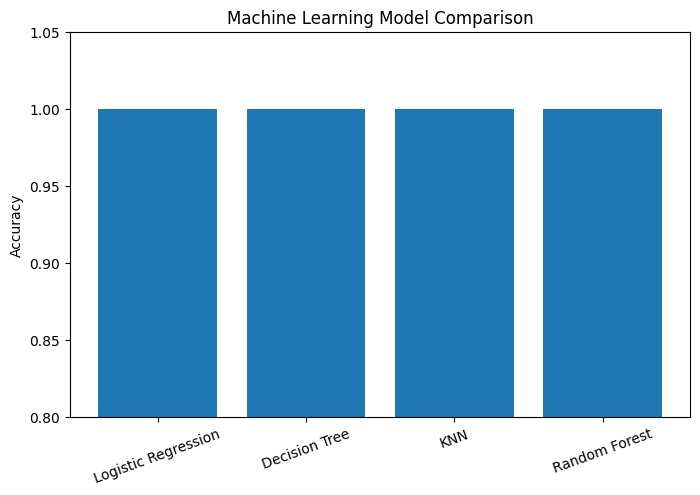


Accuracy Scores
Logistic Regression = 100.0 %
Decision Tree = 100.0 %
KNN = 100.0 %
Random Forest = 100.0 %


In [9]:
names = list(accuracy_scores.keys())

values = list(accuracy_scores.values())

plt.figure(figsize=(8,5))

plt.bar(names,values)

plt.ylim(0.8,1.05)

plt.ylabel("Accuracy")

plt.title("Machine Learning Model Comparison")

plt.xticks(rotation=20)

plt.show()

print("\nAccuracy Scores")

for model,score in accuracy_scores.items():
    print(model,"=",round(score*100,2),"%")

In [10]:
sample = [[5.1,3.5,1.4,0.2]]

sample = scaler.transform(sample)

result = best_model.predict(sample)

print("Predicted Flower:",iris.target_names[result][0])

Predicted Flower: setosa
